# 05 Ablation 3: Feature Selection Method

**Research question**: Which feature selection method maximizes
per-class Recall on the UNSW-NB15 multiclass classification task?

**Design**:

* Model: Random Forest (fixed)
* Class imbalance strategy: Capped_SMOTENC_50k (fixed, selected from Ablation 1)
* Encoding: Ordinal Encoding (fixed, selected from Ablation 2)
* Number of selected features: Top 30 (fixed)
* Variable: feature selection method (3 conditions)
* Train/test split: loaded from baseline processed files

**Feature selection methods compared**:

1. Random Forest Feature Importance (baseline)
2. Mutual Information
3. Permutation Importance

**Primary metric**: Per-class Recall
**Secondary metrics**: Macro F1

**Outputs**:

* `data/outputs/ablation3_feature_selection_results.csv`
* `reports/ablation3_feature_selection_heatmap.png`
* `reports/ablation3_macro_f1.png`

> **Note on experimental control**:
> To ensure a fair comparison, the class imbalance strategy (Capped_SMOTENC_50k),
> encoding method (Ordinal Encoding), train/test split, and classifier
> configuration remain fixed across all conditions. Only the feature
> selection method is varied.

> **Note on permutation importance**:
> Permutation Importance is computed on a sampled subset of the training
> data to reduce runtime and memory consumption on the full UNSW-NB15
> dataset (~2 M training rows).


In [1]:
# Ablation 3: Feature Selection 방법 비교
# 고정 조건:
# - Class imbalance strategy: Capped_SMOTENC_50k
# - Encoding strategy: Ordinal Encoding
# - Feature 개수: Top 30

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json

warnings.filterwarnings("ignore")

from pathlib import Path
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, f1_score, make_scorer, recall_score
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTENC

RANDOM_STATE = 42

PROJECT_ROOT = Path("..")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "data" / "outputs"
REPORT_DIR = PROJECT_ROOT / "reports"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# 전처리된 baseline 데이터 로드

X_train = pd.read_csv(PROCESSED_DIR / "X_train_baseline.csv")
X_test = pd.read_csv(PROCESSED_DIR / "X_test_baseline.csv")
y_train = pd.read_csv(PROCESSED_DIR / "y_train_baseline.csv").squeeze()
y_test = pd.read_csv(PROCESSED_DIR / "y_test_baseline.csv").squeeze()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2032037, 43)
X_test: (508010, 43)
y_train: (2032037,)
y_test: (508010,)


In [3]:
# Ordinal Encoding 적용
# Ablation 2에서 Ordinal Encoding이 최종 선택되었으므로 고정

NOMINAL_CATEGORICAL_COLS = ["proto", "state", "service"]
NUMERIC_LIKE_COLS = ["sport", "dsport", "ct_ftp_cmd"]

X_train_enc = X_train.copy()
X_test_enc = X_test.copy()
encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

X_train_enc[NOMINAL_CATEGORICAL_COLS] = encoder.fit_transform(
    X_train_enc[NOMINAL_CATEGORICAL_COLS].astype(str)
)

X_test_enc[NOMINAL_CATEGORICAL_COLS] = encoder.transform(
    X_test_enc[NOMINAL_CATEGORICAL_COLS].astype(str)
)

num_imputer = SimpleImputer(strategy="mean")

X_train_enc[NUMERIC_LIKE_COLS] = num_imputer.fit_transform(
    X_train_enc[NUMERIC_LIKE_COLS].apply(pd.to_numeric, errors="coerce")
)

X_test_enc[NUMERIC_LIKE_COLS] = num_imputer.transform(
    X_test_enc[NUMERIC_LIKE_COLS].apply(pd.to_numeric, errors="coerce")
)

print("Ordinal Encoding 완료")

Ordinal Encoding 완료


In [4]:
# SMOTENC 적용
# Ablation 1에서 Capped_SMOTENC_50k가 최종 선택되었으므로 고정

counts = y_train.value_counts()
majority_class = counts.idxmax()
second_largest = int(counts.sort_values(ascending=False).iloc[1])

OVERSAMPLE_CAP_VALUE = 50_000
OVERSAMPLE_TARGET = min(second_largest, OVERSAMPLE_CAP_VALUE)

sampling_strategy = {
    cls: OVERSAMPLE_TARGET
    for cls, cnt in counts.items()
    if cls != majority_class and cnt < OVERSAMPLE_TARGET
}

categorical_indices = [
    X_train_enc.columns.get_loc(col)
    for col in NOMINAL_CATEGORICAL_COLS
    if col in X_train_enc.columns
]

min_count = int(counts.min())
k_neighbors = min(5, min_count - 1)

smotenc = SMOTENC(
    sampling_strategy=sampling_strategy,
    random_state=RANDOM_STATE,
    k_neighbors=k_neighbors,
    categorical_features=categorical_indices
)

X_resampled, y_resampled = smotenc.fit_resample(X_train_enc, y_train)

print("Capped_SMOTENC_50k 적용 완료")
print("Majority class:", majority_class)
print("Oversample target:", OVERSAMPLE_TARGET)
print("Sampling strategy:", sampling_strategy)
print("Before:")
print(y_train.value_counts())
print("After:")
print(y_resampled.value_counts())

Capped_SMOTENC_50k 적용 완료
Majority class: Normal
Oversample target: 50000
Sampling strategy: {'Exploits': 50000, 'Fuzzers': 50000, 'DoS': 50000, 'Reconnaissance': 50000, 'Analysis': 50000, 'Backdoor': 50000, 'Shellcode': 50000, 'Worms': 50000}
Before:
attack_cat
Normal            1775011
Generic            172385
Exploits            35620
Fuzzers             19397
DoS                 13082
Reconnaissance      11189
Analysis             2142
Backdoor             1863
Shellcode            1209
Worms                 139
Name: count, dtype: int64
After:
attack_cat
Normal            1775011
Generic            172385
Exploits            50000
Shellcode           50000
DoS                 50000
Analysis            50000
Fuzzers             50000
Backdoor            50000
Reconnaissance      50000
Worms               50000
Name: count, dtype: int64


In [6]:
# 공통 모델 함수
# 같은 모델을 사용해야 feature selection 방법만 비교 가능함

ATTACK_CLASSES = [
    cls for cls in sorted(y_train.unique())
    if cls != "Normal"
]

attack_recall_scorer = make_scorer(
    recall_score,
    labels=ATTACK_CLASSES,
    average="macro",
    zero_division=0
)

def train_and_evaluate(X_train_sel, X_test_sel, y_train, y_test, method_name):
    model = RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight=None
    )
    
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )
    
    rows = []
    
    for cls in sorted(y_test.unique()):
        rows.append({
            "method": method_name,
            "class": cls,
            "recall": report[cls]["recall"],
            "f1_score": report[cls]["f1-score"]
        })
    
    attack_recalls = [
    row["recall"]
    for row in rows
    if row["class"] != "Normal"
    ]
    avg_attack_recall = np.mean(attack_recalls)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    
    return rows, avg_attack_recall, macro_f1




In [7]:
# 방법 1: Random Forest Feature Importance
# RandomForest가 자체적으로 계산한 feature_importances_ 기준으로 Top 30 선택

rf_selector = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight=None
)

rf_selector.fit(X_resampled, y_resampled)

rf_importance = pd.Series(
    rf_selector.feature_importances_,
    index=X_resampled.columns
).sort_values(ascending=False)

top30_rf = rf_importance.head(30).index.tolist()

print("RF Importance Top 30")
print(top30_rf)

RF Importance Top 30
['sttl', 'ct_state_ttl', 'sbytes', 'dsport', 'smeansz', 'dmeansz', 'dload', 'dbytes', 'service', 'dttl', 'sload', 'ct_dst_src_ltm', 'ct_srv_dst', 'sport', 'state', 'ct_src_dport_ltm', 'dur', 'ackdat', 'synack', 'proto', 'ct_dst_ltm', 'dintpkt', 'ct_srv_src', 'dpkts', 'tcprtt', 'sintpkt', 'ct_dst_sport_ltm', 'ct_src_ ltm', 'ct_flw_http_mthd', 'dloss']


In [8]:
# 방법 2: Mutual Information
# 각 feature와 target 사이의 정보량을 기준으로 Top 30 선택

mi_scores = mutual_info_classif(
    X_resampled,
    y_resampled,
    random_state=RANDOM_STATE
)

mi_importance = pd.Series(
    mi_scores,
    index=X_resampled.columns
).sort_values(ascending=False)

top30_mi = mi_importance.head(30).index.tolist()

print("Mutual Information Top 30")
print(top30_mi)

Mutual Information Top 30
['sbytes', 'sload', 'sttl', 'smeansz', 'ct_state_ttl', 'dsport', 'dttl', 'dbytes', 'proto', 'dmeansz', 'sport', 'dur', 'dload', 'dpkts', 'dintpkt', 'state', 'service', 'sintpkt', 'tcprtt', 'synack', 'ackdat', 'spkts', 'ct_dst_sport_ltm', 'ct_dst_ltm', 'dloss', 'sjit', 'sloss', 'djit', 'ct_srv_dst', 'ct_src_dport_ltm']


In [9]:
# 방법 3: Permutation Importance
# 전체 train 데이터가 너무 크므로 일부 sample로 계산
# feature 값을 섞었을 때 성능이 얼마나 떨어지는지 기준

sample_size = min(30000, len(X_resampled))

sample_idx = X_resampled.sample(
    n=sample_size,
    random_state=RANDOM_STATE
).index

X_perm_sample = X_resampled.loc[sample_idx]
y_perm_sample = y_resampled.loc[sample_idx] 


perm_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_model.fit(X_perm_sample, y_perm_sample)

perm_result = permutation_importance(
    perm_model,
    X_perm_sample,
    y_perm_sample,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring="recall_macro"
)

perm_importance = pd.Series(
    perm_result.importances_mean,
    index=X_perm_sample.columns
).sort_values(ascending=False)

top30_perm = perm_importance.head(30).index.tolist()

print("Permutation Importance Top 30")
print(top30_perm)

Permutation Importance Top 30
['dsport', 'proto', 'sttl', 'ct_src_ ltm', 'ct_ftp_cmd', 'ct_dst_src_ltm', 'dmeansz', 'ct_dst_ltm', 'ct_srv_dst', 'ct_state_ttl', 'dur', 'ct_dst_sport_ltm', 'ct_srv_src', 'sload', 'sintpkt', 'sport', 'smeansz', 'sbytes', 'ct_src_dport_ltm', 'service', 'ct_flw_http_mthd', 'dload', 'sjit', 'ackdat', 'stcpb', 'dtcpb', 'tcprtt', 'dpkts', 'sloss', 'trans_depth']


In [10]:
feature_sets = {
    "Random Forest Importance": top30_rf,
    "Mutual Information": top30_mi,
    "Permutation Importance": top30_perm
}

all_rows = []
summary_rows = []

for method_name, selected_features in feature_sets.items():
    rows, avg_attack_recall, macro_f1 = train_and_evaluate(
        X_resampled[selected_features],
        X_test_enc[selected_features],
        y_resampled,
        y_test,
        method_name
    )
    
    all_rows.extend(rows)
    
    summary_rows.append({
        "method": method_name,
        "avg_attack_recall": avg_attack_recall,
        "macro_f1": macro_f1
    })

results_df = pd.DataFrame(all_rows)
summary_df = pd.DataFrame(summary_rows)

macro_f1_df = summary_df[["method", "macro_f1"]].copy()

print(summary_df.sort_values(
    ["avg_attack_recall", "macro_f1"],
    ascending=[False, False]
))

                     method  avg_attack_recall  macro_f1
1        Mutual Information           0.610758  0.598003
0  Random Forest Importance           0.607030  0.601391
2    Permutation Importance           0.605004  0.608550


In [11]:
# 결과 저장

results_df.to_csv(
    OUTPUT_DIR / "ablation3_feature_selection_results.csv",
    index=False
)

summary_df.to_csv(
    OUTPUT_DIR / "ablation3_feature_selection_summary.csv",
    index=False
)

print("Ablation 3 결과 저장 완료")

Ablation 3 결과 저장 완료


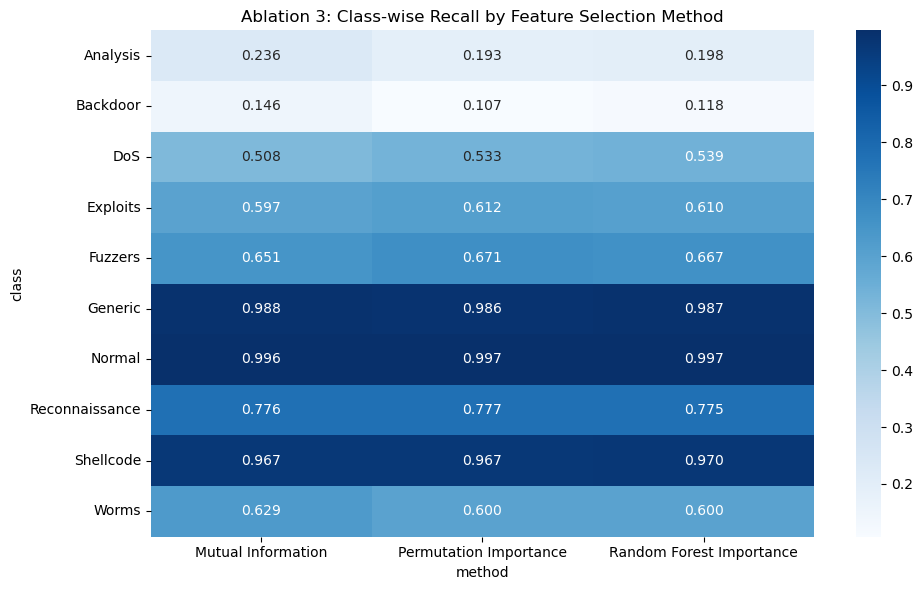

In [12]:
# 클래스별 Recall heatmap 저장

recall_pivot = results_df.pivot(
    index="class",
    columns="method",
    values="recall"
)

plt.figure(figsize=(10, 6))
sns.heatmap(recall_pivot, annot=True, fmt=".3f", cmap="Blues")
plt.title("Ablation 3: Class-wise Recall by Feature Selection Method")
plt.tight_layout()
plt.savefig(REPORT_DIR / "ablation3_feature_selection_heatmap.png", dpi=300)
plt.show()

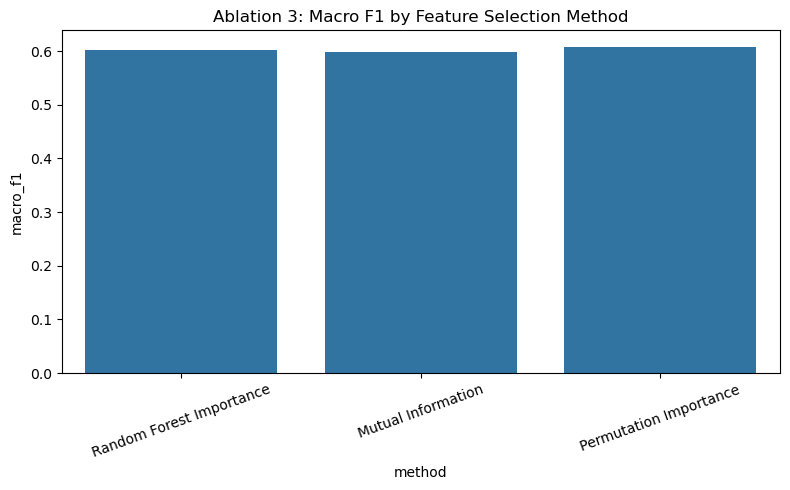

In [13]:
# Macro F1 bar plot 저장

plt.figure(figsize=(8, 5))
sns.barplot(data=macro_f1_df, x="method", y="macro_f1")
plt.title("Ablation 3: Macro F1 by Feature Selection Method")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(REPORT_DIR / "ablation3_macro_f1.png", dpi=300)
plt.show()

In [14]:
# Ablation 3 최종 선택 방법 출력

best_method = summary_df.sort_values(
    ["avg_attack_recall", "macro_f1"],
    ascending=[False, False]
).iloc[0]

print("\n=== Ablation 3 Summary ===")
print(summary_df.sort_values(
    ["avg_attack_recall", "macro_f1"],
    ascending=[False, False]
))

print("\n=== Ablation 3 최종 선택 방법 ===")
print(best_method)

best_config = {
    "best_feature_selection_method": best_method["method"],
    "imbalance_strategy": "Capped_SMOTENC_50k",
    "encoding_strategy": "Ordinal Encoding",
    "num_features": 30,
    "selection_metric": "avg_attack_recall",
    "avg_attack_recall": float(best_method["avg_attack_recall"]),
    "macro_f1": float(best_method["macro_f1"])
}

with open(OUTPUT_DIR / "ablation3_best_config.json", "w") as f:
    json.dump(best_config, f, indent=2)

print("Saved:", OUTPUT_DIR / "ablation3_best_config.json")


=== Ablation 3 Summary ===
                     method  avg_attack_recall  macro_f1
1        Mutual Information           0.610758  0.598003
0  Random Forest Importance           0.607030  0.601391
2    Permutation Importance           0.605004  0.608550

=== Ablation 3 최종 선택 방법 ===
method               Mutual Information
avg_attack_recall              0.610758
macro_f1                       0.598003
Name: 1, dtype: object
Saved: ..\data\outputs\ablation3_best_config.json
